<a href="https://colab.research.google.com/github/jooha-yoo/scikit-learn/blob/main/scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Regression in `scikit-learn`: Housing Price Prediction

- Hannah Yoo, CS 375: Artificial Intelligence
- 3/2/2026

### Overview
This project explores regression modeling using scikit-learn on the Ames Housing dataset. The goal is to evaluate how different model families—linear models, decision trees, and ensemble methods—behave on structured tabular data and how their inductive biases affect predictive performance.

The focus is on implementing a reproducible machine learning workflow, training multiple regression models, and comparing their performance both quantitatively and visually.

## Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import sklearn

## Dataset Loading

The dataset consists of housing records from the Ames, Iowa assessor’s database. Each row represents a property with structured attributes describing location, physical characteristics, and sale price.

In [3]:
ames = pd.read_csv('https://github.com/kcarnold/AmesHousing/blob/master/data/ames.csv.gz?raw=true', compression="gzip")

In [4]:
ames.head()
ames.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   MS_SubClass         2930 non-null   object 
 1   MS_Zoning           2930 non-null   object 
 2   Lot_Frontage        2930 non-null   int64  
 3   Lot_Area            2930 non-null   int64  
 4   Street              2930 non-null   object 
 5   Alley               2930 non-null   object 
 6   Lot_Shape           2930 non-null   object 
 7   Land_Contour        2930 non-null   object 
 8   Utilities           2930 non-null   object 
 9   Lot_Config          2930 non-null   object 
 10  Land_Slope          2930 non-null   object 
 11  Neighborhood        2930 non-null   object 
 12  Condition_1         2930 non-null   object 
 13  Condition_2         2930 non-null   object 
 14  Bldg_Type           2930 non-null   object 
 15  House_Style         2930 non-null   object 
 16  Overal

A derived target variable is created to normalize price scale for interpretability.

In [5]:
ames["price"] = ames["Sale_Price"] / 100_000

## Feature Section
Only geographic coordinates are used to evaluate how well location alone explains housing prices.

In [6]:
feature_names = ["Longitude", "Latitude"]

X = ames[feature_names].values
y = ames["price"].values

## Train, validation split

In [7]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Data Visualizing

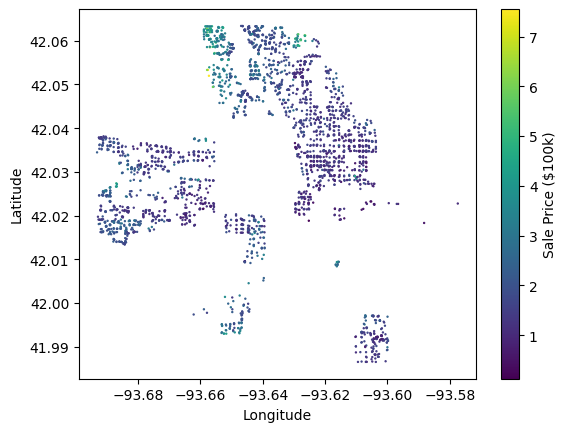

In [8]:
def plot_data():
    plt.scatter(
        ames["Longitude"],
        ames["Latitude"],
        c=ames["price"],
        s=0.5,
        cmap="viridis"
    )
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.colorbar(label="Sale Price ($100k)")

plot_data()

## Model Visualization Utility
This function visualizes model predictions across geographic space

In [9]:
def plot_model(clf):
    lon_min, lon_max = ames.Longitude.min(), ames.Longitude.max()
    lat_min, lat_max = ames.Latitude.min(), ames.Latitude.max()

    xx, yy = np.meshgrid(
        np.linspace(lon_min, lon_max, 250),
        np.linspace(lat_min, lat_max, 250)
    )

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    fig = plt.figure(figsize=(10, 12))

    ax1 = fig.add_subplot(2, 1, 1)
    surf = ax1.contourf(xx, yy, Z, alpha=0.6, cmap="viridis")
    ax1.scatter(ames.Longitude, ames.Latitude, c=ames.price, s=1, cmap="viridis")
    ax1.set_title("2D Decision Surface")
    plt.colorbar(surf, ax=ax1)

    ax2 = fig.add_subplot(2, 1, 2, projection="3d")
    ax2.plot_surface(xx, yy, Z, cmap="viridis", alpha=0.6)
    ax2.set_title("3D Decision Surface")

#Model 1 : Linear Regression

### training

In [10]:
linreg = LinearRegression()
linreg.fit(X_train, y_train)

LinearRegression()

### model params

In [11]:
linreg.coef_, linreg.intercept_

(array([-7.954917  , 11.88579514]), np.float64(-1242.7420086488416))

### example prediction

In [12]:
example_home = X_valid[0]
linreg.predict([example_home])

array([1.55432848])

### validation predictions

In [13]:
y_pred = linreg.predict(X_valid)

### evaluating

In [14]:
mse = mean_squared_error(y_valid, y_pred)
print("Mean absolute error:", mse)

mae = mean_absolute_error(y_valid, y_pred)
print("Mean absolute error:", mae)

r2 = r2_score(y_valid, y_pred)
print("r^2:", r2)

Mean absolute error: 0.6786574994305143
Mean absolute error: 0.5821366485782273
r^2: 0.15353483973038673


### visualizing

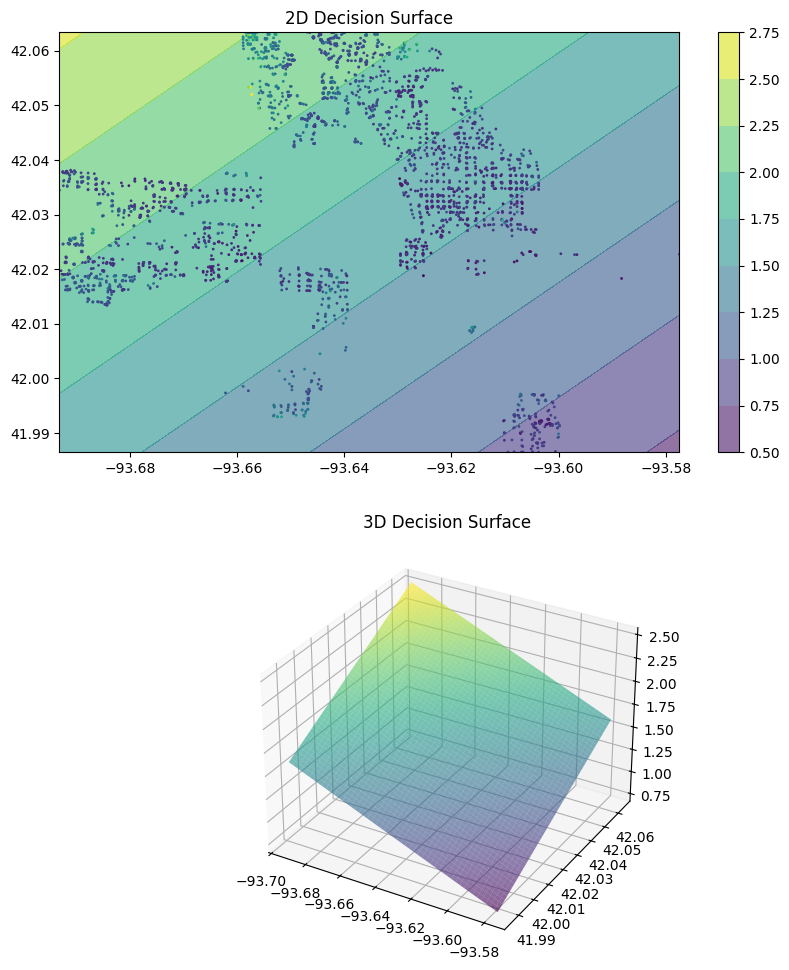

In [15]:
plot_model(linreg)

# Model 2: Decision Tree Regressor

### Small tree (interpretability check)

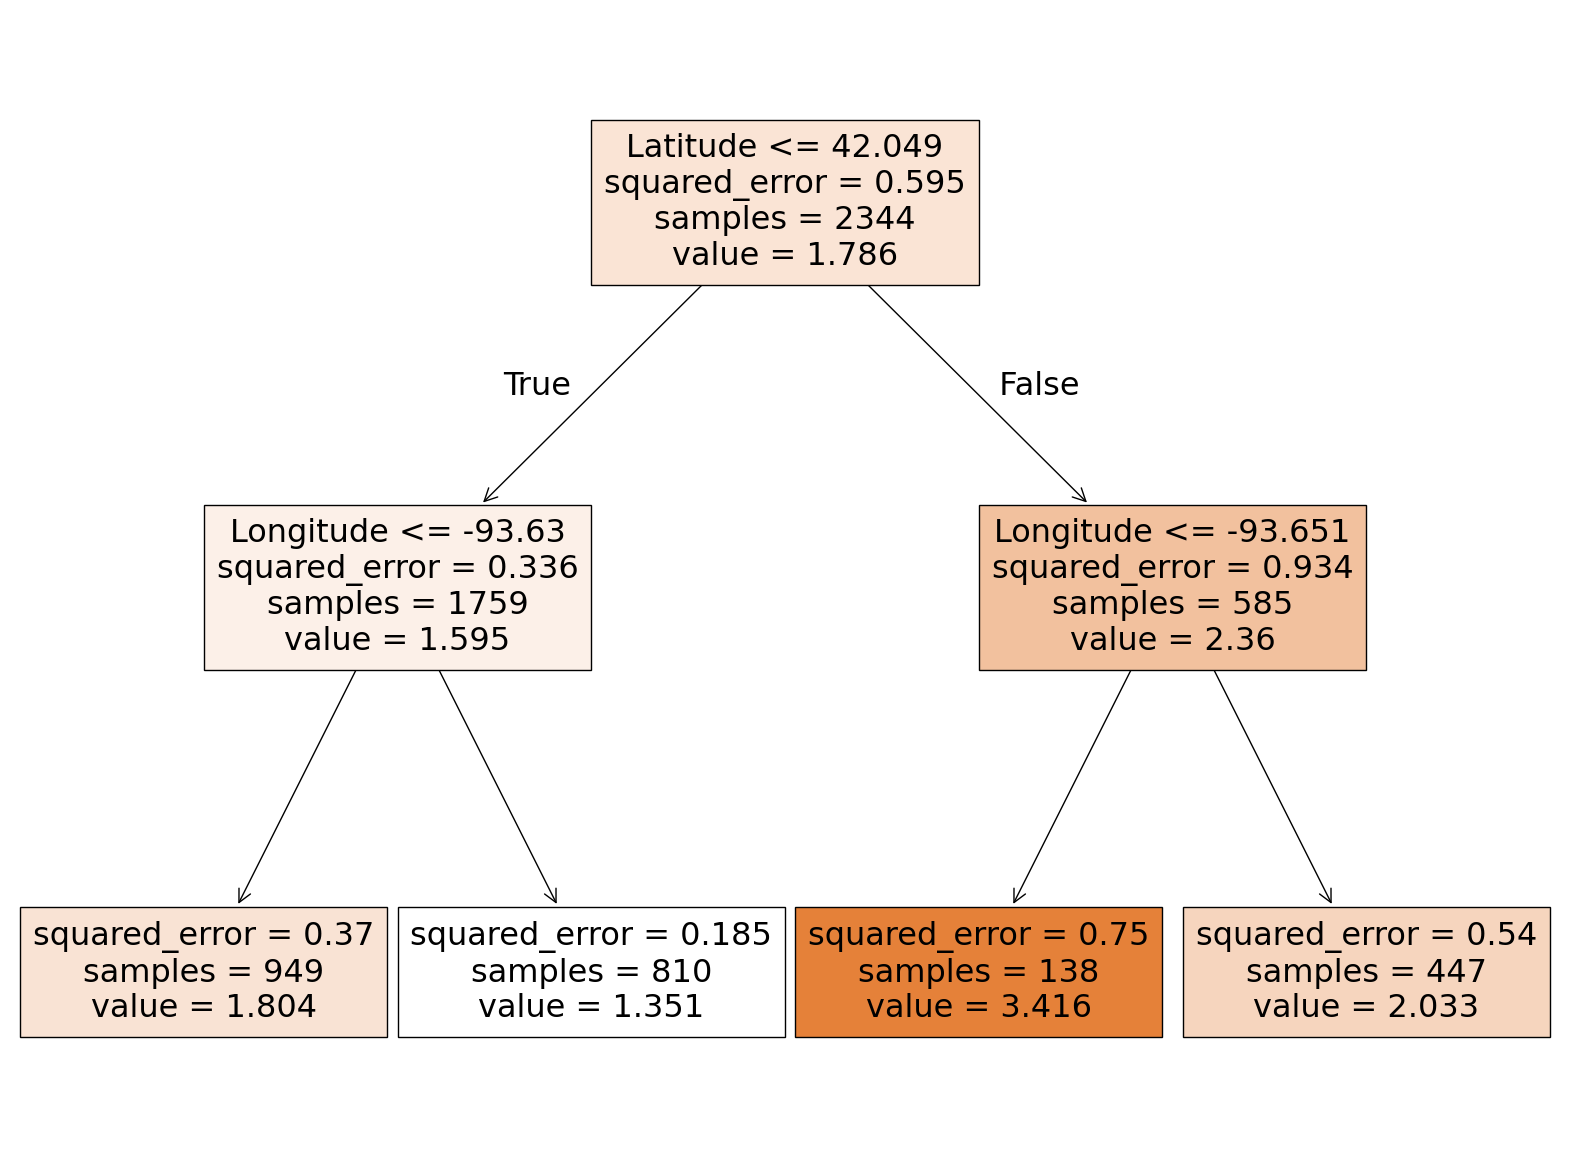

In [16]:
dtree_reg_small = DecisionTreeRegressor(max_depth=2, random_state=42)
dtree_reg_small.fit(X_train, y_train)

plt.figure(figsize=(20, 15))
sklearn.tree.plot_tree(dtree_reg_small, feature_names=feature_names, filled=True)

plt.show()

In [17]:
sklearn.tree.plot_tree(dt_small, feature_names=feature_names, filled=True)

NameError: name 'dt_small' is not defined

### Full tree

In [ ]:
dtree_reg = DecisionTreeRegressor(random_state=42)
dtree_reg.fit(X_train, y_train)

### Visualizing

In [ ]:
print(sklearn.tree.export_text(dtree_reg, feature_names=feature_names, max_depth=2))

In [ ]:
plot_model(dtree_reg)

### Evaluation

In [ ]:
mae = mean_absolute_error(y_valid, y_pred)
print("Mean absolute error:", mae)

mse = mean_squared_error(y_valid, y_pred)
print("Mean saqure error:", mse)

r2 = r2_score(y_valid, y_pred)
print("r^2score:", r2)

# Model 3: Random Forest Regressor

### Training

In [ ]:
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train, y_train)
print(f"We just fit a random forest with {rf_reg.n_estimators} trees.")

In [ ]:
plot_model(rf_reg)

### Prediction

In [ ]:
y_pred_rd = rd.predict(X_valid)

### Evaluation

In [ ]:
y_pred_rf = rf_reg.predict(X_valid)

mae = mean_absolute_error(y_valid, y_pred_rf)
print("Mean absolute error:", mae)

mse = mean_squared_error(y_valid, y_pred_rf)
print("Mean saqure error:", mse)

In [ ]:
plot_model(rf)

## Model Comparison Results

Across models, performance differences reflect underlying inductive bias:

- **Linear Regression**: produces a smooth global plane and underfits spatial variation
- **Decision Trees**: produce piecewise constant regions with sharp discontinuities
- **Random Forest:  **aggregates multiple trees, producing smoother and more accurate approximations <br> <br>

## Performance Ranking
**Best Performance**: Random Forest Regressor (lowest error, highest R²)

**Worst Performance**: Linear Regression (limited by linear spatial assumption)


## Key Insights:
- Linear models cannot capture localized spatial effects in housing prices.
- Decision trees capture locality but overfit and create blocky regions.
- Random forests improve generalization through ensemble averaging and better approximate smooth spatial gradients.

## Conclusion:
- This project demonstrates how model complexity and inductive bias directly influence predictive performance on structured tabular data. Ensemble methods provide a strong balance between bias and variance, particularly in spatial regression problems where relationships are non-linear and locally varying.